# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Retener a un cliente cuesta menos que conseguir uno nuevo, pero solo si se sabe a quién ofrecerle algo antes de que se vaya. Queremos estimar la **probabilidad de que un cliente abandone la compañía telefónica** a partir de su contrato, sus servicios y su facturación.

Es un problema de **clasificación binaria supervisada desbalanceada**: la variable objetivo `Churn` vale "Yes" en cerca del 26 % de los clientes. Los dos errores posibles no cuestan lo mismo: no detectar a quien se va pierde un cliente, y contactar a quien se iba a quedar cuesta una campaña.

El asistente JarvisTEC usa este modelo para responder con la probabilidad de abandono y una clasificación de riesgo alto o bajo.

# Caso Aplicado: Abandono de Clientes de Telefonía
## Clasificación binaria desbalanceada, probabilidades y umbral de decisión

---

**Temas:** Desbalance de clases · Variables categóricas · Selección de variables · Umbral de decisión · Calibración  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Qué variables hay y cuáles vienen sucias o son redundantes? |
| 2 — Exploración | ¿Qué características se asocian con el abandono? |
| 3 — Modelo | ¿Cuántas variables hacen falta y qué clasificador rinde mejor? |
| 4 — Evaluación | ¿Qué umbral conviene y las probabilidades son confiables? |

> Nota: con clases desbalanceadas la exactitud engaña. Predecir siempre "No" acierta alrededor del 73 % sin detectar a nadie, así que hay que mirar el AUC, el recall y la calibración.

Este notebook es un extra del modelo 04 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto de IBM tiene 7 043 clientes y 21 columnas (IBM, 2018): el identificador, 19 variables predictoras y el objetivo. **Es un conjunto de ejemplo ficticio** (una muestra de IBM Cognos Analytics), no datos reales de una compañía, así que las conclusiones tienen una validez limitada.

- Cuenta     : tenure (meses), Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
- Servicios  : PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- Demografía : gender, SeniorCitizen, Partner, Dependents
- Churn      : variable objetivo, "Yes" si el cliente abandonó

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_04_churn/` del repositorio. Son 7 043 filas y 21 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print("Filas y columnas:", datos.shape)
print("Abandono:", datos["Churn"].value_counts(normalize=True).round(3).to_dict())
print("Valores nulos:", int(datos.isna().sum().sum()))

Filas y columnas: (7043, 21)
Abandono: {'No': 0.735, 'Yes': 0.265}
Valores nulos: 0


### Limpieza

`TotalCharges` viene como texto y tiene 11 cadenas vacías. Se revisa a quién corresponden.

In [6]:
vacios = datos[pd.to_numeric(datos["TotalCharges"], errors="coerce").isna()]
print("Filas con TotalCharges vacío:", len(vacios), "| antigüedad (tenure):", vacios["tenure"].unique(), "| abandonos:", (vacios["Churn"] == "Yes").sum())

Filas con TotalCharges vacío: 11 | antigüedad (tenure): [0] | abandonos: 0


Todos los vacíos son clientes con 0 meses de antigüedad (ninguno ha abandonado), así que se llenan con 0. Además, `TotalCharges` es casi igual a `tenure` por `MonthlyCharges`, es decir, redundante. Se verifica y se descarta.

In [7]:
df = datos.copy()
df.columns = ["customerID"] + ["".join("_" + c.lower() if c.isupper() else c for c in col).lstrip("_") for col in df.columns[1:]]
df = df.drop(columns="customerID")
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce").fillna(0)
df["senior_citizen"] = df["senior_citizen"].map({0: "No", 1: "Yes"})
print("Correlación total_charges vs tenure * monthly_charges: %.4f" % df["total_charges"].corr(df["tenure"] * df["monthly_charges"]))
df.head()

Correlación total_charges vs tenure * monthly_charges: 0.9996


,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Hay otra cosa que conviene saber: sin servicio de internet, los seis servicios adicionales valen siempre "No internet service", y sin teléfono, `MultipleLines` vale "No phone service". Son categorías que dependen unas de otras.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

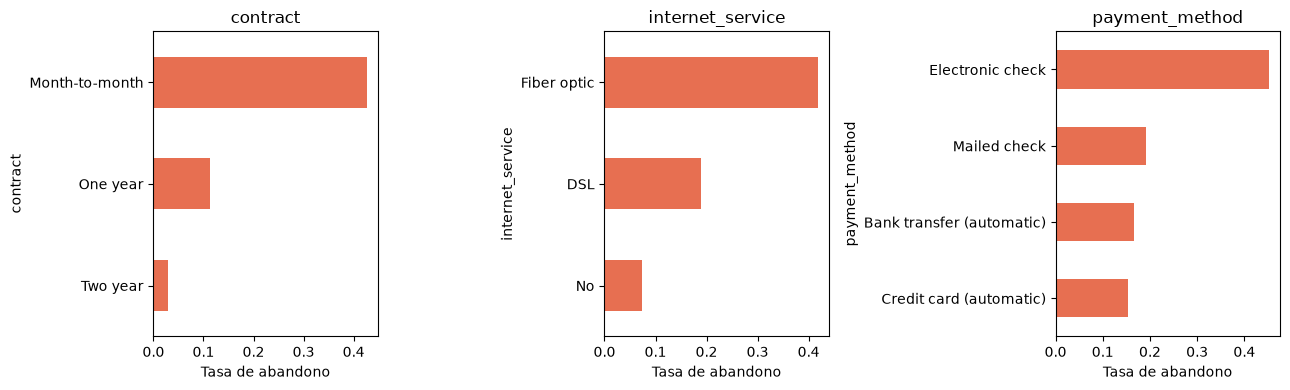

Por contrato: {'Month-to-month': 0.427, 'One year': 0.113, 'Two year': 0.028}
Por internet: {'DSL': 0.19, 'Fiber optic': 0.419, 'No': 0.074}
Por método de pago: {'Bank transfer (automatic)': 0.167, 'Credit card (automatic)': 0.152, 'Electronic check': 0.453, 'Mailed check': 0.191}


In [8]:
OBJETIVO = "churn"
tasa = lambda col: df.groupby(col)[OBJETIVO].apply(lambda s: (s == "Yes").mean())

fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
for eje, col in zip(ejes, ["contract", "internet_service", "payment_method"]):
    tasa(col).sort_values().plot.barh(ax=eje, color="#e76f51")
    eje.set_xlabel("Tasa de abandono")
    eje.set_title(col)
plt.tight_layout()
plt.show()
print("Por contrato:", tasa("contract").round(3).to_dict())
print("Por internet:", tasa("internet_service").round(3).to_dict())
print("Por método de pago:", tasa("payment_method").round(3).to_dict())

El **tipo de contrato** es la señal más fuerte: los clientes mes a mes abandonan mucho más que los de uno o dos años. También abandonan más quienes tienen fibra óptica y quienes pagan con cheque electrónico.

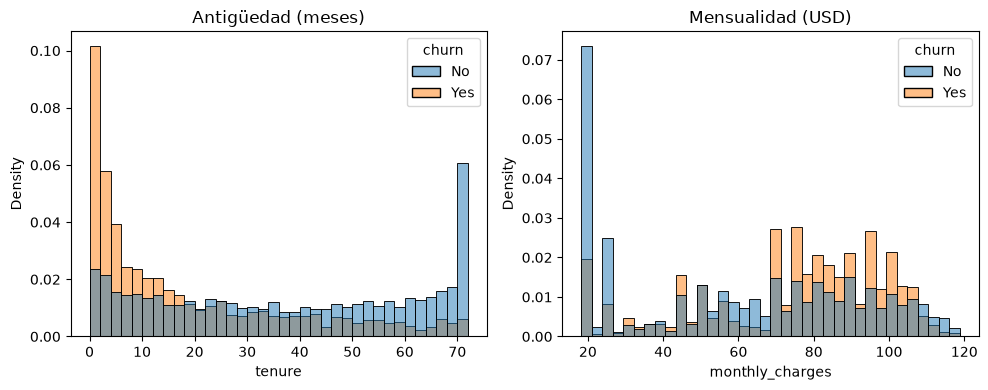

Mediana de antigüedad: {'No': 38.0, 'Yes': 10.0}
Mediana de mensualidad: {'No': 64.4, 'Yes': 79.6}
Sin soporte técnico: 0.416 | con soporte: 0.152


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data=df, x="tenure", hue=OBJETIVO, bins=36, stat="density", common_norm=False, ax=ejes[0])
ejes[0].set_title("Antigüedad (meses)")
sns.histplot(data=df, x="monthly_charges", hue=OBJETIVO, bins=36, stat="density", common_norm=False, ax=ejes[1])
ejes[1].set_title("Mensualidad (USD)")
plt.tight_layout()
plt.show()
print("Mediana de antigüedad:", df.groupby(OBJETIVO)["tenure"].median().to_dict())
print("Mediana de mensualidad:", df.groupby(OBJETIVO)["monthly_charges"].median().round(1).to_dict())
print("Sin soporte técnico:", round(tasa("tech_support")["No"], 3), "| con soporte:", round(tasa("tech_support")["Yes"], 3))

Quienes abandonan tienen **poca antigüedad** y **mensualidades más altas**. Los clientes sin soporte técnico también abandonan bastante más.

> Analogía: un cliente nuevo con un contrato mes a mes es como un huésped que reservó una sola noche. Puede irse en cualquier momento. Uno con contrato de dos años ya dejó una reserva larga y es mucho más probable que se quede.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

La división es estratificada por abandono. Para trabajar más cómodo se codifica el objetivo como 1 ("Yes") y 0 ("No").

In [10]:
y = (df[OBJETIVO] == "Yes").astype(int)
train, test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=SEMILLA)
print("Entrenamiento:", len(train), " Prueba:", len(test))
print("Abandono en entrenamiento: %.3f   en prueba: %.3f" % (y_train.mean(), y_test.mean()))

Entrenamiento: 5634  Prueba: 1409
Abandono en entrenamiento: 0.265   en prueba: 0.265


### Cuántas variables hacen falta

Un formulario con 18 campos sería incómodo. Se mide con regresión logística y validación cruzada (solo con el entrenamiento) cuánto se pierde al reducir las variables.

In [11]:
def armar(estimador, variables, escalar=True):
    numericas = [v for v in variables if v in ("tenure", "monthly_charges", "total_charges")]
    categoricas = [v for v in variables if v not in numericas]
    columnas = ColumnTransformer([
        ("num", StandardScaler() if escalar else "passthrough", numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
    ])
    return Pipeline([("pre", columnas), ("modelo", estimador)])

TODAS = [c for c in df.columns if c not in (OBJETIVO, "total_charges")]
VARIABLES = ["tenure", "monthly_charges", "contract", "internet_service", "payment_method", "paperless_billing",
             "tech_support", "online_security", "senior_citizen"]
CONJUNTOS = {"18 (todas, sin total_charges)": TODAS, "9 (las elegidas)": VARIABLES,
             "6 mínimas": VARIABLES[:6], "3 (antigüedad, mensualidad, contrato)": ["tenure", "monthly_charges", "contract"]}

validacion = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEMILLA)
filas = {}
for nombre, cols in CONJUNTOS.items():
    r = cross_validate(armar(LogisticRegression(max_iter=3000), cols), train[cols], y_train, cv=validacion, scoring="roc_auc")
    filas[nombre] = {"variables": len(cols), "AUC cv": r["test_score"].mean(), "desviación": r["test_score"].std()}
pd.DataFrame(filas).T.round(4).astype({"variables": int})

,variables,AUC cv,desviación
"18 (todas, sin total_charges)",18,0.8450,0.0116
9 (las elegidas),9,0.8426,0.0110
6 mínimas,6,0.8389,0.0117
"3 (antigüedad, mensualidad, contrato)",3,0.8276,0.0126


Con 9 variables se pierden unas milésimas de AUC, mucho menos que la desviación entre pliegues. Un formulario de 9 campos es razonable, y son las que se usan en el resto del notebook.

### Candidatos

Se entrenan sin pesos de clase: la aplicación le muestra al usuario una probabilidad, y los pesos de clase la distorsionan (Niculescu-Mizil y Caruana, 2005). El desbalance se maneja con el **umbral de decisión**.

In [12]:
def candidatos():
    return {
        "tasa base (línea base)": armar(DummyClassifier(strategy="prior"), VARIABLES),
        "regresión logística": armar(LogisticRegression(max_iter=3000), VARIABLES),
        "random forest": armar(RandomForestClassifier(n_estimators=150, min_samples_leaf=10, max_depth=10, random_state=SEMILLA, n_jobs=-1), VARIABLES, escalar=False),
        "gradient boosting": armar(HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, early_stopping=False, random_state=SEMILLA), VARIABLES, escalar=False),
    }

filas = {}
for nombre, pipe in candidatos().items():
    r = cross_validate(pipe, train[VARIABLES], y_train, cv=validacion, scoring={"auc": "roc_auc", "pr": "average_precision"})
    filas[nombre] = {"AUC ROC cv": r["test_auc"].mean(), "desviación": r["test_auc"].std(), "AUC PR cv": r["test_pr"].mean()}
comparacion = pd.DataFrame(filas).T.round(4)
comparacion

,AUC ROC cv,desviación,AUC PR cv
tasa base (línea base),0.5000,0.0000,0.2654
regresión logística,0.8426,0.0110,0.6503
random forest,0.8452,0.0110,0.6553
gradient boosting,0.8387,0.0116,0.6501


Los tres modelos reales casi no se distinguen entre sí (las diferencias son menores que la desviación). Se elige el de mayor AUC, pero la regresión logística, más simple, rinde casi igual.

In [13]:
ganador = comparacion.drop("tasa base (línea base)")["AUC ROC cv"].idxmax()
print("Modelo elegido:", ganador)
modelo = candidatos()[ganador].fit(train[VARIABLES], y_train)

Modelo elegido: random forest


### Umbral de decisión

Con clases desbalanceadas, el umbral de 0.5 casi no detecta abandonos. Se elige el umbral que maximiza el F1 de la clase "Yes", pero con predicciones **fuera de muestra del entrenamiento** (validación cruzada) y nunca con la prueba.

In [14]:
oof = cross_val_predict(candidatos()[ganador], train[VARIABLES], y_train, method="predict_proba",
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA))[:, 1]
rejilla = np.round(np.arange(0.05, 0.951, 0.01), 2)
puntajes = [f1_score(y_train, oof >= t, zero_division=0) for t in rejilla]
umbral = float(rejilla[int(np.argmax(puntajes))])
print("Umbral elegido (F1 de 'Yes' fuera de muestra):", umbral)

Umbral elegido (F1 de 'Yes' fuera de muestra): 0.35


##### Evaluación en el conjunto de prueba

In [15]:
p_yes = modelo.predict_proba(test[VARIABLES])[:, 1]
base = candidatos()["tasa base (línea base)"].fit(train[VARIABLES], y_train).predict_proba(test[VARIABLES])[:, 1]
print("AUC ROC: %.3f (línea base %.3f)" % (roc_auc_score(y_test, p_yes), roc_auc_score(y_test, base)))
print("AUC PR:  %.3f (tasa base %.3f)" % (average_precision_score(y_test, p_yes), y_test.mean()))
print("Brier:   %.3f (tasa base %.3f)" % (brier_score_loss(y_test, p_yes), brier_score_loss(y_test, base)))

def al_umbral(t):
    pred = (p_yes >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    return {"exactitud": (pred == y_test).mean(), "precisión Yes": precision_score(y_test, pred), "recall Yes": recall_score(y_test, pred),
            "F1 Yes": f1_score(y_test, pred), "TN": tn, "FP": fp, "FN": fn, "TP": tp}

pd.DataFrame({"umbral %.2f (elegido)" % umbral: al_umbral(umbral), "umbral 0.50": al_umbral(0.5)}).T.round(3).astype({"TN": int, "FP": int, "FN": int, "TP": int})

AUC ROC: 0.840 (línea base 0.500)
AUC PR:  0.649 (tasa base 0.265)
Brier:   0.138 (tasa base 0.195)


,exactitud,precisión Yes,recall Yes,F1 Yes,TN,FP,FN,TP
umbral 0.35 (elegido),0.769,0.552,0.690,0.614,826,209,116,258
umbral 0.50,0.801,0.656,0.529,0.586,931,104,176,198


Con el umbral elegido el modelo detecta mucho más abandono (mayor recall) a costa de contactar a más clientes que se habrían quedado. Predecir siempre "No" acierta alrededor del 73 % pero detecta a 0 clientes. **El umbral óptimo depende del costo de la campaña de retención**; aquí se usó el F1, que da el mismo peso a los dos errores.

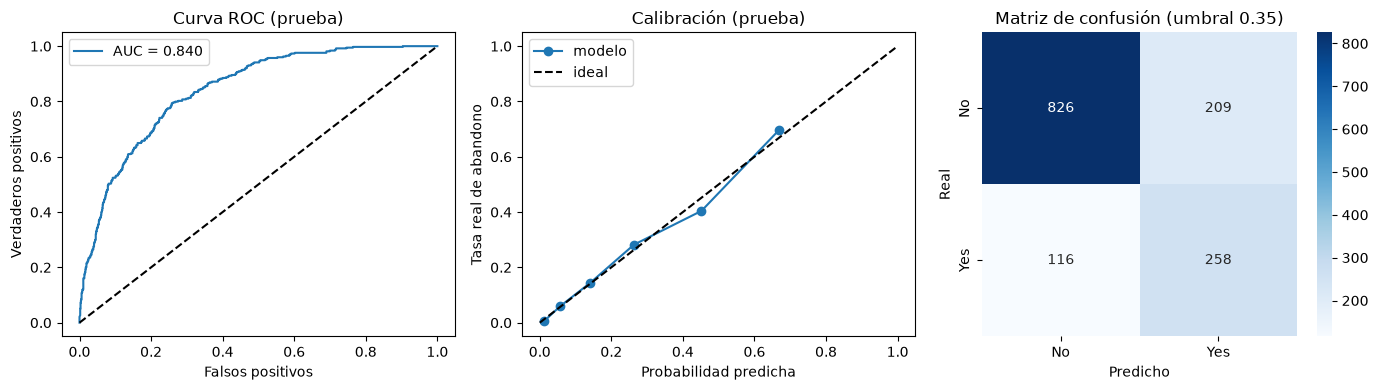

,prob. media predicha,tasa real
0,0.011,0.004
1,0.057,0.060
2,0.142,0.145
3,0.263,0.282
4,0.452,0.404
5,0.670,0.698


In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
fpr, tpr, _ = roc_curve(y_test, p_yes)
ejes[0].plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, p_yes))
ejes[0].plot([0, 1], [0, 1], "k--")
ejes[0].set(xlabel="Falsos positivos", ylabel="Verdaderos positivos", title="Curva ROC (prueba)")
ejes[0].legend()
frac, media = calibration_curve(y_test, p_yes, n_bins=6, strategy="quantile")
ejes[1].plot(media, frac, "o-", label="modelo")
ejes[1].plot([0, 1], [0, 1], "k--", label="ideal")
ejes[1].set(xlabel="Probabilidad predicha", ylabel="Tasa real de abandono", title="Calibración (prueba)")
ejes[1].legend()
pred = (p_yes >= umbral).astype(int)
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ejes[2])
ejes[2].set(xlabel="Predicho", ylabel="Real", title="Matriz de confusión (umbral %.2f)" % umbral)
plt.tight_layout()
plt.show()
pd.DataFrame({"prob. media predicha": media, "tasa real": frac}).round(3)

Las probabilidades predichas se parecen a las frecuencias reales (la curva de calibración sigue la diagonal). Por eso la aplicación puede mostrarlas como probabilidades.

### Predicción para un cliente nuevo

In [17]:
cliente = pd.DataFrame([{"tenure": 5, "monthly_charges": 85.0, "contract": "Month-to-month", "internet_service": "Fiber optic",
                         "payment_method": "Electronic check", "paperless_billing": "Yes", "tech_support": "No",
                         "online_security": "No", "senior_citizen": "No"}])
p = modelo.predict_proba(cliente[VARIABLES])[0, 1]
print("Probabilidad de abandono: %.1f %%  ->  %s" % (100 * p, "riesgo alto" if p >= umbral else "riesgo bajo"))

Probabilidad de abandono: 75.8 %  ->  riesgo alto


---
# Conclusiones
---

## Resultados

El modelo estima la probabilidad de abandono con un AUC de aproximadamente 0.84 en la prueba, frente a 0.5 de la línea base. Con el umbral elegido detecta cerca de 7 de cada 10 clientes que se van, y su precisión duplica la tasa base. Las probabilidades están razonablemente calibradas.

Con solo 9 variables se rinde casi igual que con 18, lo que permite un formulario corto. El contrato mes a mes, la poca antigüedad, la fibra óptica, el cheque electrónico y la falta de soporte técnico son las señales más fuertes de abandono.

Limitaciones: el conjunto es de ejemplo y no son datos reales de una compañía. Los tres modelos rinden parecido, así que la elección entre ellos no es concluyente. El umbral depende del costo de la campaña de retención, que aquí no se conoce.

### Referencias

> IBM. (2018). *Telco Customer Churn* [Conjunto de datos de ejemplo de IBM Cognos Analytics].
> Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of the 22nd International Conference on Machine Learning*.
> Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861-874.